In [52]:
from pathlib import Path
from PIL import Image
import numpy as np
import shutil
import matplotlib.pyplot as plt # for plotting

In [53]:
repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

In [54]:
input_root = repo_root / "data" / "raw"
output_root = repo_root / "data" / "processed"
output_root.mkdir(parents=True, exist_ok=True)

(64, 192) uint8 50 255


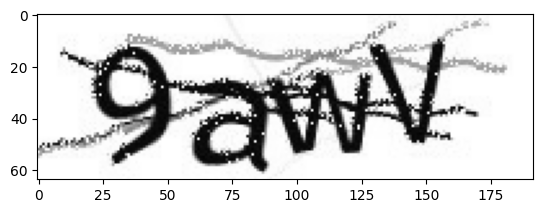

In [55]:
img_path = input_root / "4Char_2000_CapGen" / "000017.png"

if not img_path.exists():
    raise FileNotFoundError(f"Missing file: {img_path}")

img = Image.open(img_path).convert("L")
arr = np.array(img)
print(arr.shape, arr.dtype, arr.min(), arr.max())

plt.imshow(arr, cmap="gray")

In [56]:
h, w = arr.shape
slice_width = w // 4

left_outer   = arr[:, 0:slice_width]
left_centre  = arr[:, slice_width:2*slice_width]
right_centre = arr[:, 2*slice_width:3*slice_width]
right_outer  = arr[:, 3*slice_width:w]

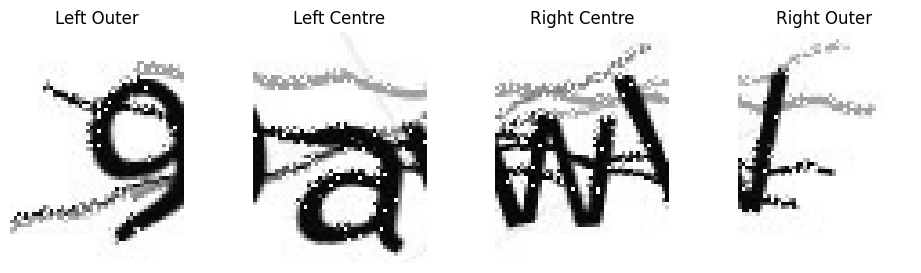

In [57]:

fig, axs = plt.subplots(1, 4, figsize=(12,3))

axs[0].imshow(left_outer, cmap="gray")
axs[0].set_title("Left Outer")

axs[1].imshow(left_centre, cmap="gray")
axs[1].set_title("Left Centre")

axs[2].imshow(right_centre, cmap="gray")
axs[2].set_title("Right Centre")

axs[3].imshow(right_outer, cmap="gray")
axs[3].set_title("Right Outer")

for ax in axs:
    ax.axis("off")

plt.show()

In [58]:
left_outer_mean = np.mean(left_outer)
left_centre_mean = np.mean(left_centre)
right_centre_mean = np.mean(right_centre)
right_outer_mean = np.mean(right_outer)

centre_mean = (left_centre_mean + right_centre_mean) / 2
outer_mean = (left_outer_mean + right_outer_mean) / 2

print("centre_mean:", centre_mean)
print("outer_mean:", outer_mean)

centre_mean: 201.833984375
outer_mean: 225.32991536458334


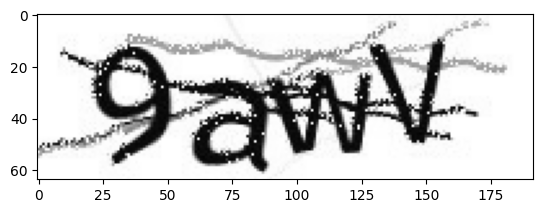

In [59]:
if centre_mean > outer_mean:
    arr = 255 - arr

plt.imshow(arr, cmap="gray")

In [60]:
processed_img = Image.fromarray(arr.astype(np.uint8))
processed_img.show()

In [61]:
test_output = output_root = repo_root / "data" / "processed" / "test_output2.jpg"
processed_img.save(test_output)